### Interest rate (neeeded for greeks )

In [ ]:
import pandas as pd 

YEAR = "2020"

# Stock price data
df_stock = pd.read_csv(f's3://us-options-historical/stocks/AAPL_{YEAR}.csv.zst')
df_stock["date"] = pd.to_datetime(df_stock["timestamp"]).dt.date

# Option chain data, with greeks 
df_option = pd.read_csv(f's3://us-options-historical/options/AAPL_{YEAR}.csv.zst', on_bad_lines="warn")
df_option["trade_date"] = pd.to_datetime(df_option["trade_date"])

# Interest rate, lagging
df_irate_historical = pd.read_xml(
    f"https://markets.newyorkfed.org/read?startDt={YEAR}-01-01&endDt={YEAR}-12-31&eventCodes=510,515,520,500,505&productCode=50&sort=postDt:-1,eventCode:1&format=xml",
    xpath=".//rate"
    ).query(
        "`type`==\"SOFR\""
    ).eval(
        """
        rate=percentRate*0.01
        """
    ).set_index("effectiveDate")["rate"]
df_irate_historical.index = pd.to_datetime(df_irate_historical.index)
df_irate_historical.sort_index(inplace=True)

# SR1 continuation
# https://www.cmegroup.com/markets/interest-rates/stirs/one-month-sofr.html
# https://www.marketwatch.com/investing/future/sr1c00/download-data?startDate=1/1/2020&endDate=12/31/2020
df_irate_sr1 = 1 - 0.01 * pd.read_csv("SR1.csv", parse_dates=["Date"], index_col=["Date"])["Close"]

# CTFC DTCC DATA
## df = pd.read_csv(
# "http://pddata.dtcc.com/ppd/api/report/cumulative/cftc/CFTC_CUMULATIVE_RATES_YYYY_MM_DD.zip"
# ).query(
# "`UPI Underlier Name` == \"USD-SOFR-OIS Compound\" & "
# "`Event type` == \"TRAD\" & "
# "`Non-standardized term indicator` == False &"
# "`Cleared` != \"N\" &"
# "`Spread-Leg 2`.isna()"
# )

<Axes: >

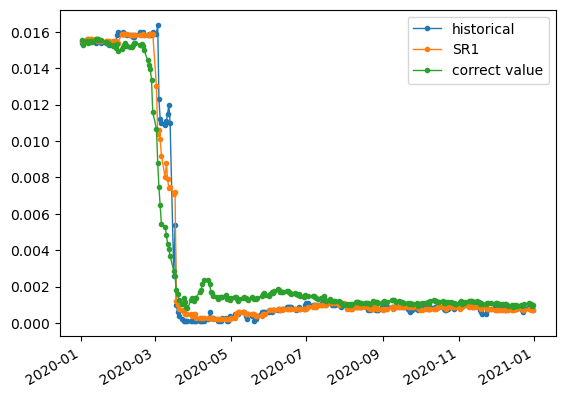

In [136]:
df_irate_option = df_option.groupby("trade_date")["iRate"].mean()

pd.DataFrame({
    "historical": df_irate_historical, 
    "SR1": df_irate_sr1,
    "correct value": df_irate_option,
}).plot(marker=".", lw=1)

### Option instrument selection

In [488]:
# https://cdn.cboe.com/resources/options/Cboe2020OPTIONSCalendar.pdf
calendar = [31, 28, 31, 30, 29, 30, 31, 31, 30, 30, 30, 31, 31, 31,]
df_option["expirDate_"] = pd.to_datetime(df_option.expirDate)
monthly_filter = df_option["expirDate_"].apply(lambda x: calendar[x.month-1] == x.day)
df_option_monthly = df_option.loc[monthly_filter]
nearest = df_option_monthly.groupby("trade_date")["expirDate_"].min().to_dict()
nearest_filter = df_option_monthly["trade_date"].map(nearest) == df_option_monthly["expirDate_"]
df_option_monthly = df_option_monthly.loc[nearest_filter].groupby(["trade_date","strike"])[["cValue","delta","stkPx","expirDate_"]].last()
# df_option_monthly = df_option_monthly.reset_index("strike") 


In [494]:
import numpy as np
stk = df_option_monthly.iloc[0]["stkPx"]
for d in df_option_monthly.index.get_level_values(0).unique():
    data = df_option_monthly.loc[d]
    if abs(np.log(stk / (data["stkPx"].mean()))) > 0.10: # trade call after 10% price drift
        stk = data.eval("abs(strike - stkPx)").idxmin()
    df_option_monthly.loc[d,"selected_strike"] = stk
df = df_option_monthly.query("selected_strike == strike").reset_index("strike")

In [495]:
df = df.eval("continuous = (strike.diff() == 0) and (expirDate_.diff() == \"0 days\")").drop(["selected_strike", "expirDate_"], axis=1)
df["continuous"] = df["continuous"].shift(-1)

df_stock_adj_ret = df_stock.groupby("date")["close"].last().pct_change()
df = df.reindex(df_stock_adj_ret.index)
df["stock_chg"] = df["stkPx"].ffill() * df_stock_adj_ret 

df["cValue_chg"] = df["cValue"].ffill().diff().shift(-1)

/tmp/nix-shell-1680392-2446965837/ipykernel_1681460/351907676.py:1: FutureWarning: The behavior of 'isin' with dtype=timedelta64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df = df.eval("continuous = (strike.diff() == 0) and (expirDate_.diff() == \"0 days\")").drop(["selected_strike", "expirDate_"], axis=1)


In [507]:
df.dropna(axis=0).query("continuous == True")

,strike,cValue,delta,stkPx,continuous,stock_chg,cValue_chg
date,,,,,,,
2020-04-09,267.5,15.60,0.527964,267.90,True,1.933206,2.33
2020-04-13,267.5,17.93,0.575153,272.65,True,5.331117,9.46
2020-04-14,267.5,27.39,0.716442,287.66,True,14.591983,-1.67
2020-04-15,267.5,25.72,0.683097,284.44,True,-2.615631,0.93
2020-04-16,267.5,26.65,0.694123,285.69,True,2.279896,-3.34
...,...,...,...,...,...,...,...
2020-12-23,128.0,4.58,0.753791,131.76,True,-0.919163,-0.06
2020-12-24,128.0,4.52,0.772812,131.81,True,0.936036,4.36
2020-12-28,128.0,8.88,0.948902,136.71,True,5.016881,-1.57


### Greek estimation, Delta hedge 

TODO: calculate delta 

<Axes: title={'center': 'Option cloning'}, xlabel='date', ylabel='USD'>

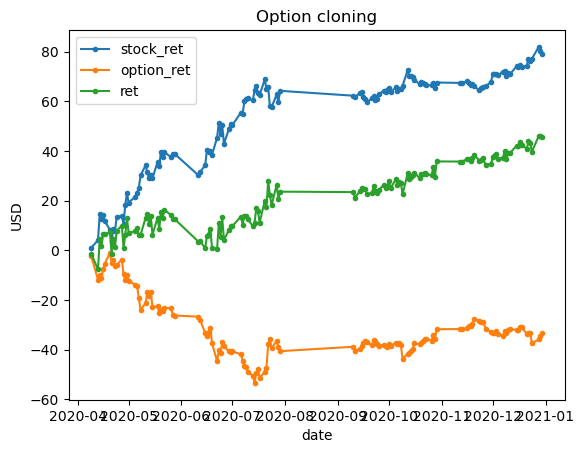

In [503]:
df_ret = df.query("continuous==True").eval("""
stock_ret = stock_chg * delta 
option_ret = -cValue_chg
ret = stock_ret + option_ret
""")[["stock_ret","option_ret","ret"]]

df_ret.cumsum().plot(marker=".", ylabel="USD", title="Option cloning")